In [72]:
# test 
import ngsolve as ngs
from netgen.meshing import Mesh as NetMesh
from netgen.geom2d import unit_square

mesh = ngs.Mesh(unit_square.GenerateMesh(maxh=0.2))

V = H1(mesh, order=1)
u = V.TrialFunction()
v = V.TestFunction()

print("NGSolve")

NGSolve


In [328]:
# create the stationary FOM using ngsolve
# here define mesh, FE-space, operators

# here we tell ngsolve what to do when pyMOR calls it

import numpy as np
from ngsolve import *
from ngsolve.webgui import Draw
from ngsolve.meshes import Make1DMesh


alpha = 1.0
beta = Parameter(3.25)  # solve for different beta later
nu = 0.01
h = 50                  # (compare 50 and 100 later)
order = 2               # quadratic Lagrange basis functions

mesh = Make1DMesh(h)   # mesh on (0,1) into h pieces

# V_h = V_u * V_v 
V_h = H1(mesh, order=order, dirichlet="right") * H1(mesh, order=order, dirichlet="right")

u, v = V_h.TrialFunction()    # represent unknowns 
phi, psi = V_h.TestFunction() # test functions ("for u and v")


# This holds the values where the nonlinear operator is evaluated
w_h = GridFunction(V_h)          # w_h element in V_h with zeros
u_part, v_part = w_h.components  # seperate u and v part in w_h 

# generate mass Matrix m 
m = BilinearForm(V_h)   # m: V_h x V_h to R
m += (u * phi + v * psi) * dx   # u * phi fills the upper-left block (u part)
                                # v * psi fills the lower-right block (v part)
m.Assemble()

# generate stiffness matrix a
a = BilinearForm(V_h)   # a: V_h x V_h to R
a += (nu * grad(u) * grad(phi) + nu * grad(v) * grad(psi)) * dx
a.Assemble()

# for the non-lin part we use Newtons method $$F(u + \delta u) \approx F(u) + F'(u)* \delta u$$
# for Newton we need the residual and the Jacobian

# 0 != a*v_h - f(v) (= F(u))
def spatial_residual(vec, beta):    # res(v) = a*v - f(v)
 
    beta_val = beta.item() if hasattr(beta, 'item') else float(beta)    #(both, for manual case and intern solver)
        
    w_h.vec.data = vec
   # u_part, v_part = w_h.components[0], w_h.components[1]
    u_part, v_part = list(w_h.components)
    y = alpha + u_part        # lifting part as in the paper
    z = (beta_val/alpha) + v_part
    
    
    # define the residual
    res = LinearForm(V_h)   # res: V_h to R
    
    # Linear Diffusion part: A * w_h
    #res += (nu * grad(u_part) * grad(phi) + nu * grad(v_part) * grad(psi)) * dx    # add diffusion part
    res.vec.data = a.mat * w_h.vec    # matrix-vector-mult
    
    # f_u = y^2*z - (beta+1)*y + alpha
    # f_v = beta*y - y^2*z
    res += -(y**2 * z - (beta_val + 1) * y + alpha) * phi * dx     # non-lin part
    res += -(beta_val * y - y**2 * z) * psi * dx
    
    res.Assemble()
    return res.vec  # BaseVector as input, BaseVector as output

# J_ij = \frac{\partial F_i}{u_j}
def jacobian(vec, beta):
 
    beta_val = beta.item() if hasattr(beta, 'item') else float(beta)
    
    w_h.vec.data = vec
    u_part, v_part = list(w_h.components)
   # u_part, v_part = w_h.components[0], w_h.components[1]
    
    y = alpha + u_part
    z = (beta_val/alpha) + v_part
    
    jac = BilinearForm(V_h)
    
    jac += (nu * grad(u) * grad(phi) + nu * grad(v) * grad(psi)) * dx   # linear part
    
    # d/du (y^2 z - (beta+1)y + alpha) = 2yz - (beta+1)
    # d/dv (y^2 z - (beta+1)y + alpha) = y^2
    jac += -( (2*y*z - (beta_val+1))*u + (y**2)*v ) * phi * dx   
    # d/du (beta*y - y^2 z) = beta - 2yz
    # d/dv (beta*y - y^2 z) = -y^2
    jac += -( (beta_val - 2*y*z)*u - (y**2)*v ) * psi * dx
    
    jac.Assemble()
    return jac.mat   # BaseVector as input, SparseMatrix as output


In [329]:
# bind the linear parts

from pymor.bindings.ngsolve import NGSolveMatrixOperator, NGSolveVectorSpace

# define the pyMOR VectorSpace from your NGSolve FE space
v_space = NGSolveVectorSpace(V_h)    # make it a pyMOR VectorSpace

m_op = NGSolveMatrixOperator(m.mat, range=v_space, source=v_space)   # pyMOR operator that takes VectorArray as input
a_op = NGSolveMatrixOperator(a.mat, range=v_space, source=v_space)


In [330]:
# here create the Operator A (we can plug into InstationaryModel)
# create a new Operator that inherits from Operator (pyMOR object)

from pymor.operators.interface import Operator

class BrusselatorOperator(Operator):
    def __init__(self, V_h, a_form, residual_func, jacobian_func):

        super().__init__()  # inherit from Operator

        self.linear = False
        
        self.V_h = V_h
        self.source = v_space
        self.range = v_space
        
        self.a_form = a_form
        self.residual_func = residual_func
        self.jacobian_func = jacobian_func

        self.parameters_own = {'beta': 1} # this is the parameter

    def apply(self, U, mu=None):

        gfu_impl = U.vectors[0].real_part.impl   # get the Gridfunction
    
        vec_ng = gfu_impl.vec    # get the BaseVector
        current_beta = mu['beta']   # update beta
    
        res_vec = self.residual_func(vec_ng, current_beta)  # compute in ngsolve, return basevector
    
        res_gf = GridFunction(self.V_h)  # wrap into new gridfunction
        res_gf.vec.data = res_vec
    
        return self.range.make_array([res_gf])      # make VectorArray

        
    def jacobian(self, U, mu=None):
        
        gfu_impl = U.vectors[0].real_part.impl
        vec_ng = gfu_impl.vec
        
        # compute jacobian in ngsolve
        current_beta = mu['beta']
        mat_ng = self.jacobian_func(vec_ng, current_beta)
        
      
        return NGSolveMatrixOperator(mat_ng, range=self.range, source=self.source)



In [331]:
# ingridients for the Model

# create the concrete operator we want
a_br = BrusselatorOperator(
    V_h=V_h, 
    a_form=a_op, 
    residual_func=spatial_residual, 
    jacobian_func=jacobian
)

# initial data
gfu0 = GridFunction(V_h)
gfu0.components[0].Set(alpha)   # start at steady state
gfu0.components[1].Set(beta/alpha)

# for pyMOR
u0_vec = v_space.make_array([gfu0])

In [332]:
# Test the Mass Matrix directly
try:
    test_apply = m_op.apply(u0_vec)
    print("Mass matrix apply works!")
except AttributeError as e:
    print(f"Mass matrix apply failed: {e}")

# Test your Operator directly
try:
    test_nonlinear = a_br.apply(u0_vec, mu={'beta': 1.0})
    print("Nonlinear operator apply works!")
except AttributeError as e:
    print(f"Nonlinear operator apply failed: {e}")

Mass matrix apply works!
Nonlinear operator apply works!


In [335]:
from pymor.models.basic import InstationaryModel
from pymor.algorithms.timestepping import ImplicitEulerTimeStepper

Brusselator_fom = InstationaryModel(
    T=1.0,
    initial_data=u0_vec,
    operator=a_br, # A
    mass=m_op,     # M
    rhs=None,     # f
    time_stepper=ImplicitEulerTimeStepper(nt=1000)
)

In [ ]:
Brusselator_fom.solve({'beta': 1.0})

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [173]:
from pymor.operators.interface import Operator
from pymor.bindings.ngsolve import NGSolveMatrixOperator

class NGSolveBrusselatorOperator(Operator):     
    def __init__(self, v_space, spatial_residual, jacobian_func):
        super().__init__()
        self.v_space = v_space
        self.spatial_residual = spatial_residual
        self.jacobian_func = jacobian_func
        self.source = self.range = v_space
        self.linear = False  
        self.parameters_own = {'beta': 1}

    def _get_ngs_vec(self, U, index):
        """The 'Sledgehammer' extraction."""
        # 1. Get the internal ListVector
        v = U[index].vectors[0]
        
        # 2. If it's a Complexified wrapper, get the real part
        if hasattr(v, 'real'):
            v = v.real
            
        # 3. DIRECT EXTRACTION: 
        # In pyMOR's NGSolve bindings, the actual NGSolve object 
        # is often stored in an attribute called '_vec' or 'vector'.
        if hasattr(v, '_vec'):
            return v._vec # This is usually the raw NGSolve BaseVector
        if hasattr(v, 'vector'):
            # If the object inside is also wrapped, check its .impl
            inner = v.vector
            return inner.impl if hasattr(inner, 'impl') else inner
            
        # 4. Final attempt: the .impl attribute
        return v.impl if hasattr(v, 'impl') else v

    def apply(self, U, mu=None):
        beta.Set(mu['beta'][0])
        # This list comprehension now gets the truly raw BaseVector
        res_ngs_list = [self.spatial_residual(self._get_ngs_vec(U, i)) for i in range(len(U))]
        return self.v_space.make_array(res_ngs_list)

    def jacobian(self, U, mu=None):
        beta.Set(mu['beta'][0])
        v_ngs = self._get_ngs_vec(U, 0)
        return NGSolveMatrixOperator(self.jacobian_func(v_ngs), 
                                     range=self.range, 
                                     source=self.source)

In [179]:
from pymor.models.basic import StationaryModel

nonlinear_op = NGSolveBrusselatorOperator(v_space, spatial_residual, jacobian)

rhs_zero = v_space.zeros()

fom_br = StationaryModel(
    operator=nonlinear_op,
    rhs=rhs_zero
)

print("FOM successfully created and pyMOR-compliant!")
print(f"Model Parameters: {fom.parameters}")

FOM successfully created and pyMOR-compliant!
Model Parameters: {beta: 1}


In [160]:

print(f"Total Degrees of Freedom: {v_space.V.ndof}")


print(f"Number of components in Space: {len(v_space.V.components)}")


Total Degrees of Freedom: 202
Number of components in Space: 2


In [156]:
# Create a test vector
U_test = v_space.full(1.0)
# See if the residual calculation actually finishes
res = nonlinear_op.apply(U_test, mu={'beta': [1.0]})
print("Apply finished!")

TypeError: (): incompatible function arguments. The following argument types are supported:
    1. (arg0: ngsolve.la.BaseVector, arg1: ngla::DynamicVectorExpression) -> None

Invoked with: basevector, ComplexifiedNGSolveVector(NGSolveVector(<ngsolve.comp.GridFunction object at 0x00000266ED37F830>), None)

In [178]:
from pymor.operators.interface import Operator
from pymor.bindings.ngsolve import NGSolveMatrixOperator

class NGSolveBrusselatorOperator(Operator):     
    def __init__(self, v_space, spatial_residual, jacobian_func):
        super().__init__()
        self.v_space = v_space
        self.spatial_residual = spatial_residual
        self.jacobian_func = jacobian_func
        self.source = self.range = v_space
        self.linear = False  
        self.parameters_own = {'beta': 1}
    def _get_ngs_vec(self, U, index):
        """Final version to extract raw NGSolve BaseVector."""
        # Get the internal vector object
        v = U[index].vectors[0]
        
        # Step 1: Strip the pyMOR Complexified wrapper
        # This is what caused your 'TypeError' earlier
        if hasattr(v, 'real'):
            v = v.real
            
        # Step 2: Strip the pyMOR NGSolveVector wrapper
        # This wrapper holds the '.vector' (the NGSolve object)
        if hasattr(v, 'vector'):
            v = v.vector
            
        # Step 3: Extract the raw C++ 'BaseVector' from NGSolve
        # This is what 'w_h.vec.data' is waiting for
        if hasattr(v, 'impl'):
            return v.impl
            
        return v
    def apply(self, U, mu=None):
        # Update the parameter
        beta.Set(mu['beta'][0])
        
        # We MUST ensure we are passing the raw .impl to the spatial_residual
        res_ngs_list = [self.spatial_residual(self._get_ngs_vec(U, i)) for i in range(len(U))]
        
        return self.v_space.make_array(res_ngs_list)
    def jacobian(self, U, mu=None):
        beta.Set(mu['beta'][0])
        v_ngs = self._get_ngs_vec(U, 0)
        return NGSolveMatrixOperator(self.jacobian_func(v_ngs), 
                                     range=self.range, 
                                     source=self.source)

In [182]:
# 1. Create the pyMOR vector array
U_start = v_space.zeros()

# 2. Reach past the "Complexified" and "NGSolveVector" wrappers
# This is the path: Complexified -> Real Part -> NGSolveWrapper -> C++ Implementation
U_start.vectors[0].real.vector.impl[:] = 1.0

print(f"Success! Initial guess norm: {U_start.norm()}")

AttributeError: 'ComplexifiedNGSolveVector' object has no attribute 'vector'

In [180]:
initial_guess=U_start
fom_br.solve({'beta': 1.0})

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

TypeError: (): incompatible function arguments. The following argument types are supported:
    1. (arg0: ngsolve.la.BaseVector, arg1: ngla::DynamicVectorExpression) -> None

Invoked with: basevector, ComplexifiedNGSolveVector(NGSolveVector(<ngsolve.comp.GridFunction object at 0x00000266ECBA96D0>), None)

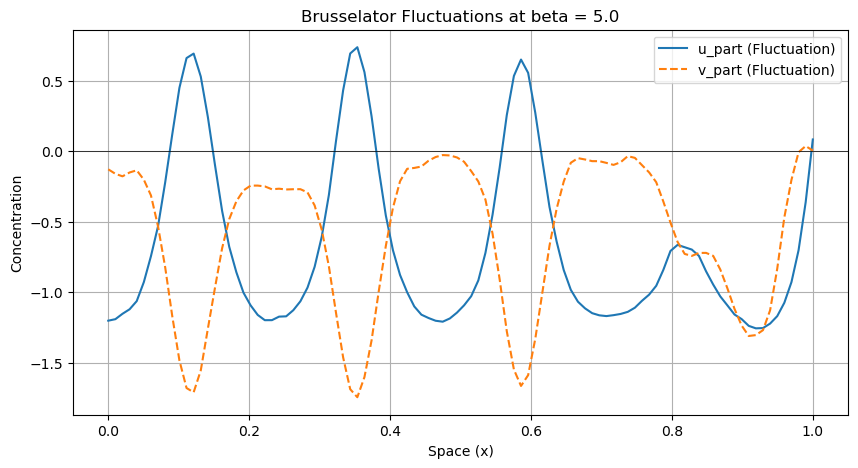

In [38]:
import matplotlib.pyplot as plt

# 1. Ensure we have a non-zero solution (Nudge + Higher Beta)
beta.Set(5.0) 
w_h.vec.SetRandom() # Fill with random values
w_h.vec.data *= 0.1 # Scale down the noise

# 2. Run the Newton loop (Manual)
for i in range(10):
    res = spatial_residual(w_h.vec)
    jac = jacobian(w_h.vec)
    inv = jac.Inverse(V_h.FreeDofs(), inverse="sparsecholesky")
    w_h.vec.data -= inv * res
    if res.Norm() < 1e-10: break

# 3. Extract data for plotting
# We sample the solution across the [0, 1] interval
x_vals = np.linspace(0, 1, 100)
u_vals = [u_part(mesh(x)) for x in x_vals]
v_vals = [v_part(mesh(x)) for x in x_vals]

# 4. Create the Plot
plt.figure(figsize=(10, 5))
plt.plot(x_vals, u_vals, label="u_part (Fluctuation)")
plt.plot(x_vals, v_vals, label="v_part (Fluctuation)", linestyle="--")
plt.axhline(0, color='black', lw=0.5)
plt.title(f"Brusselator Fluctuations at beta = {beta.Get()}")
plt.xlabel("Space (x)")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
import numpy as np
from ngsolve import *
from ngsolve.webgui import Draw   # for visualisation
import matplotlib.pyplot as plt

# parameters
alpha = 1.0
beta = 3.25  # Chosen from your range [2.75, 4.25]
nu = 0.01
h = 1/50
order = 2
T = 10.0     # Final time
dt = 0.01    # Time step for the FOM

# create Finite Element Space (fes)

mesh = Mesh(unit_interval.GenerateMesh(maxh=h)) # mesh on (0,1) into h pieces

# create the FE-space, product space since we have u and v, order = 2 means quadratic Lagrange polynomial
# (here the basis functions are generated)
# V_h = V_u * V_v
V_h = H1(mesh, order=order, dirichlet="right") * H1(mesh, order=order, dirichlet="right") 
                                                                                       
u, v = V_h.TrialFunction()    # represents unknowns
phi, psi = V_h.TestFunction()   # our test functions

# something in order to obtain the initial cond
w_h = GridFunction(V_h)  # element in V_h, v_h = (u_h,v_h)
w_h.components[0].Set(0.1 * sin(pi * x)) # u_h(x,0) = 0.1 sin(pi*x)   (for the `kick`start)
w_h.components[1].Set(0.1 * sin(pi * x)) # v_h(x,0) = 0.1 sin(pi*x)

# seperate u_h and v_h for the non-lin part 
u_part, v_part = w_h.components[0], w_h.components[1]  

# Diffusion matrix a
a = BilinearForm(V_h)         # a:V_h x V_h to R
a += nu * grad(u) * grad(phi) * dx  # upper left part of a 
a += nu * grad(v) * grad(psi) * dx  # lower right part of a
a.Assemble()   # here we loop over all basis functions

# Mass matrix m
m = BilinearForm(V_h)
m += u * phi * dx
m += v * psi * dx
m.Assemble()



print("Simulation complete.")

NameError: name 'unit_interval' is not defined